# EQUITY CLIQUET OPTION

Valuation and Risk of Equity Cliquet Options

In [20]:
import numpy as np
import matplotlib.pyplot as plt

In [21]:
from financepy.utils import *
from financepy.market.curves import *
from financepy.products.equity import *

# Cliquet Option

I create a cliquet option

In [22]:
start_dt = Date(1,1, 2020)

In [23]:
expiry_dt = Date(1, 1, 2025)

In [24]:
opt_typeCall = OptionTypes.EUROPEAN_CALL

In [25]:
freq_type = FrequencyTypes.ANNUAL

In [26]:
cliquetCall = EquityCliquetOption(start_dt, expiry_dt, opt_typeCall, freq_type)

In [27]:
print(cliquetCall)

OBJECT_TYPE: EquityCliquetOption
START_DATE: 01-JAN-2020
FINAL EXPIRY DATE: 01-JAN-2025
OPTION_TYPE: OptionTypes.EUROPEAN_CALL
FREQUENCY TYPE: FrequencyTypes.ANNUAL
CALENDAR TYPE: CalendarTypes.WEEKEND
BUS_DAY_ADJUST: BusDayAdjustTypes.FOLLOWING
DATE GEN RULE TYPE: DateGenRuleTypes.BACKWARD


## Valuation

In [28]:
value_dt = Date(1, 1, 2020)

In [29]:
interest_rate = 0.10

In [30]:
discount_curve = FlatDiscountCurve(value_dt, interest_rate)

In [31]:
dividend_yield = 0.0

In [32]:
dividend_curve = FlatDiscountCurve(value_dt, dividend_yield)

In [33]:
volatility = 0.10

In [34]:
model = BlackScholes(volatility)

In [35]:
stock_prices = np.linspace(50, 150, 20)

In [36]:
values = []

for stock_price in stock_prices:
    stock_min_max = stock_price
    v = cliquetCall.value(value_dt, stock_price, discount_curve, dividend_curve, model)
    values.append(v)

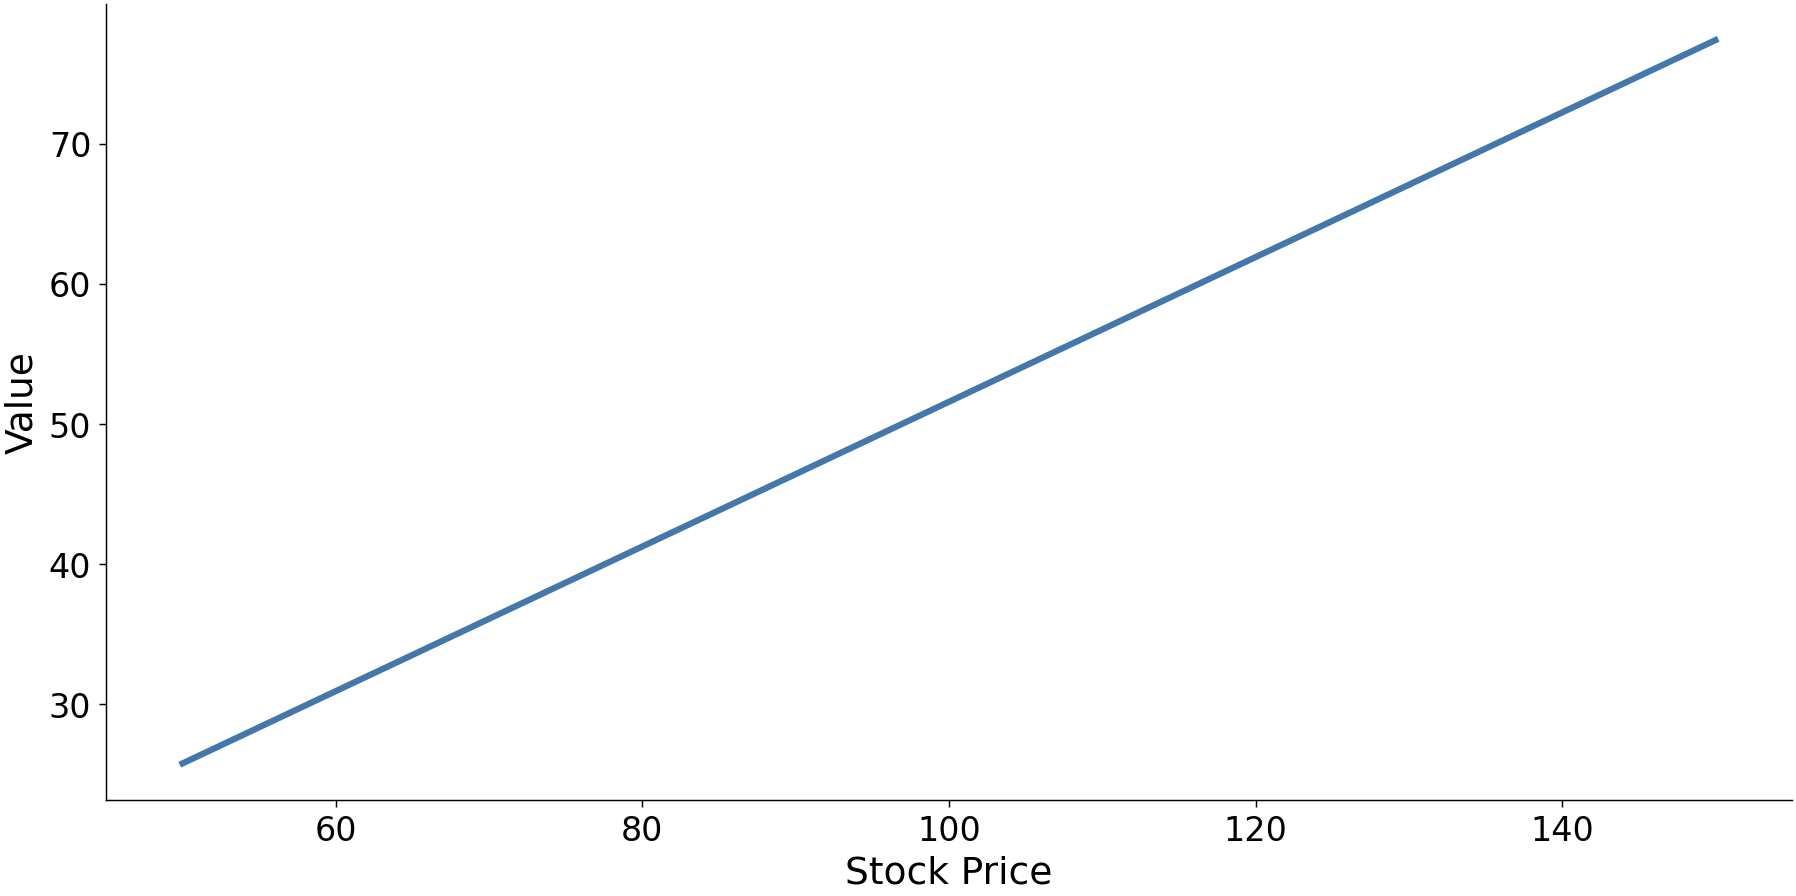

In [37]:
plt.plot(stock_prices, values)
plt.xlabel("Stock Price")
plt.ylabel("Value");

In [38]:
cliquetCall.print_payments()

01-JAN-2021 0.9045895513293778 15.497763894386802
03-JAN-2022 0.8180581001624628 15.533297246949196
02-JAN-2023 0.7404124040823471 15.426667964850171
01-JAN-2024 0.6701364218631031 15.426667964850171
01-JAN-2025 0.606198405182619 15.497763894398076


Copyright (c) 2020 Dominic O'Kane